In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L1VzZXJzL3Npc3NpeWFuZy9EL1RyYWRlX09TL3F1YW50LWZvci1iZWdpbm5lcnMvaG9tZXdvcms='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/importlib/_bootstrap.py": 1784012591.3310614, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/importlib/_bootstrap_external.py": 1784012591.331289, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/zipimport.py": 1784012591.7612646, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/codecs.py": 1784012590.9808702, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/encodings/aliases.py": 1784012591.0006135, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/encodings/__init__.py": 1784012590.9992645, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none/lib/python3.14/encodings/utf_8.py": 1784012591.0316708, "/Users/sissiyang/.local/share/uv/python/cpython-3.14.6-macos-aarch64-none

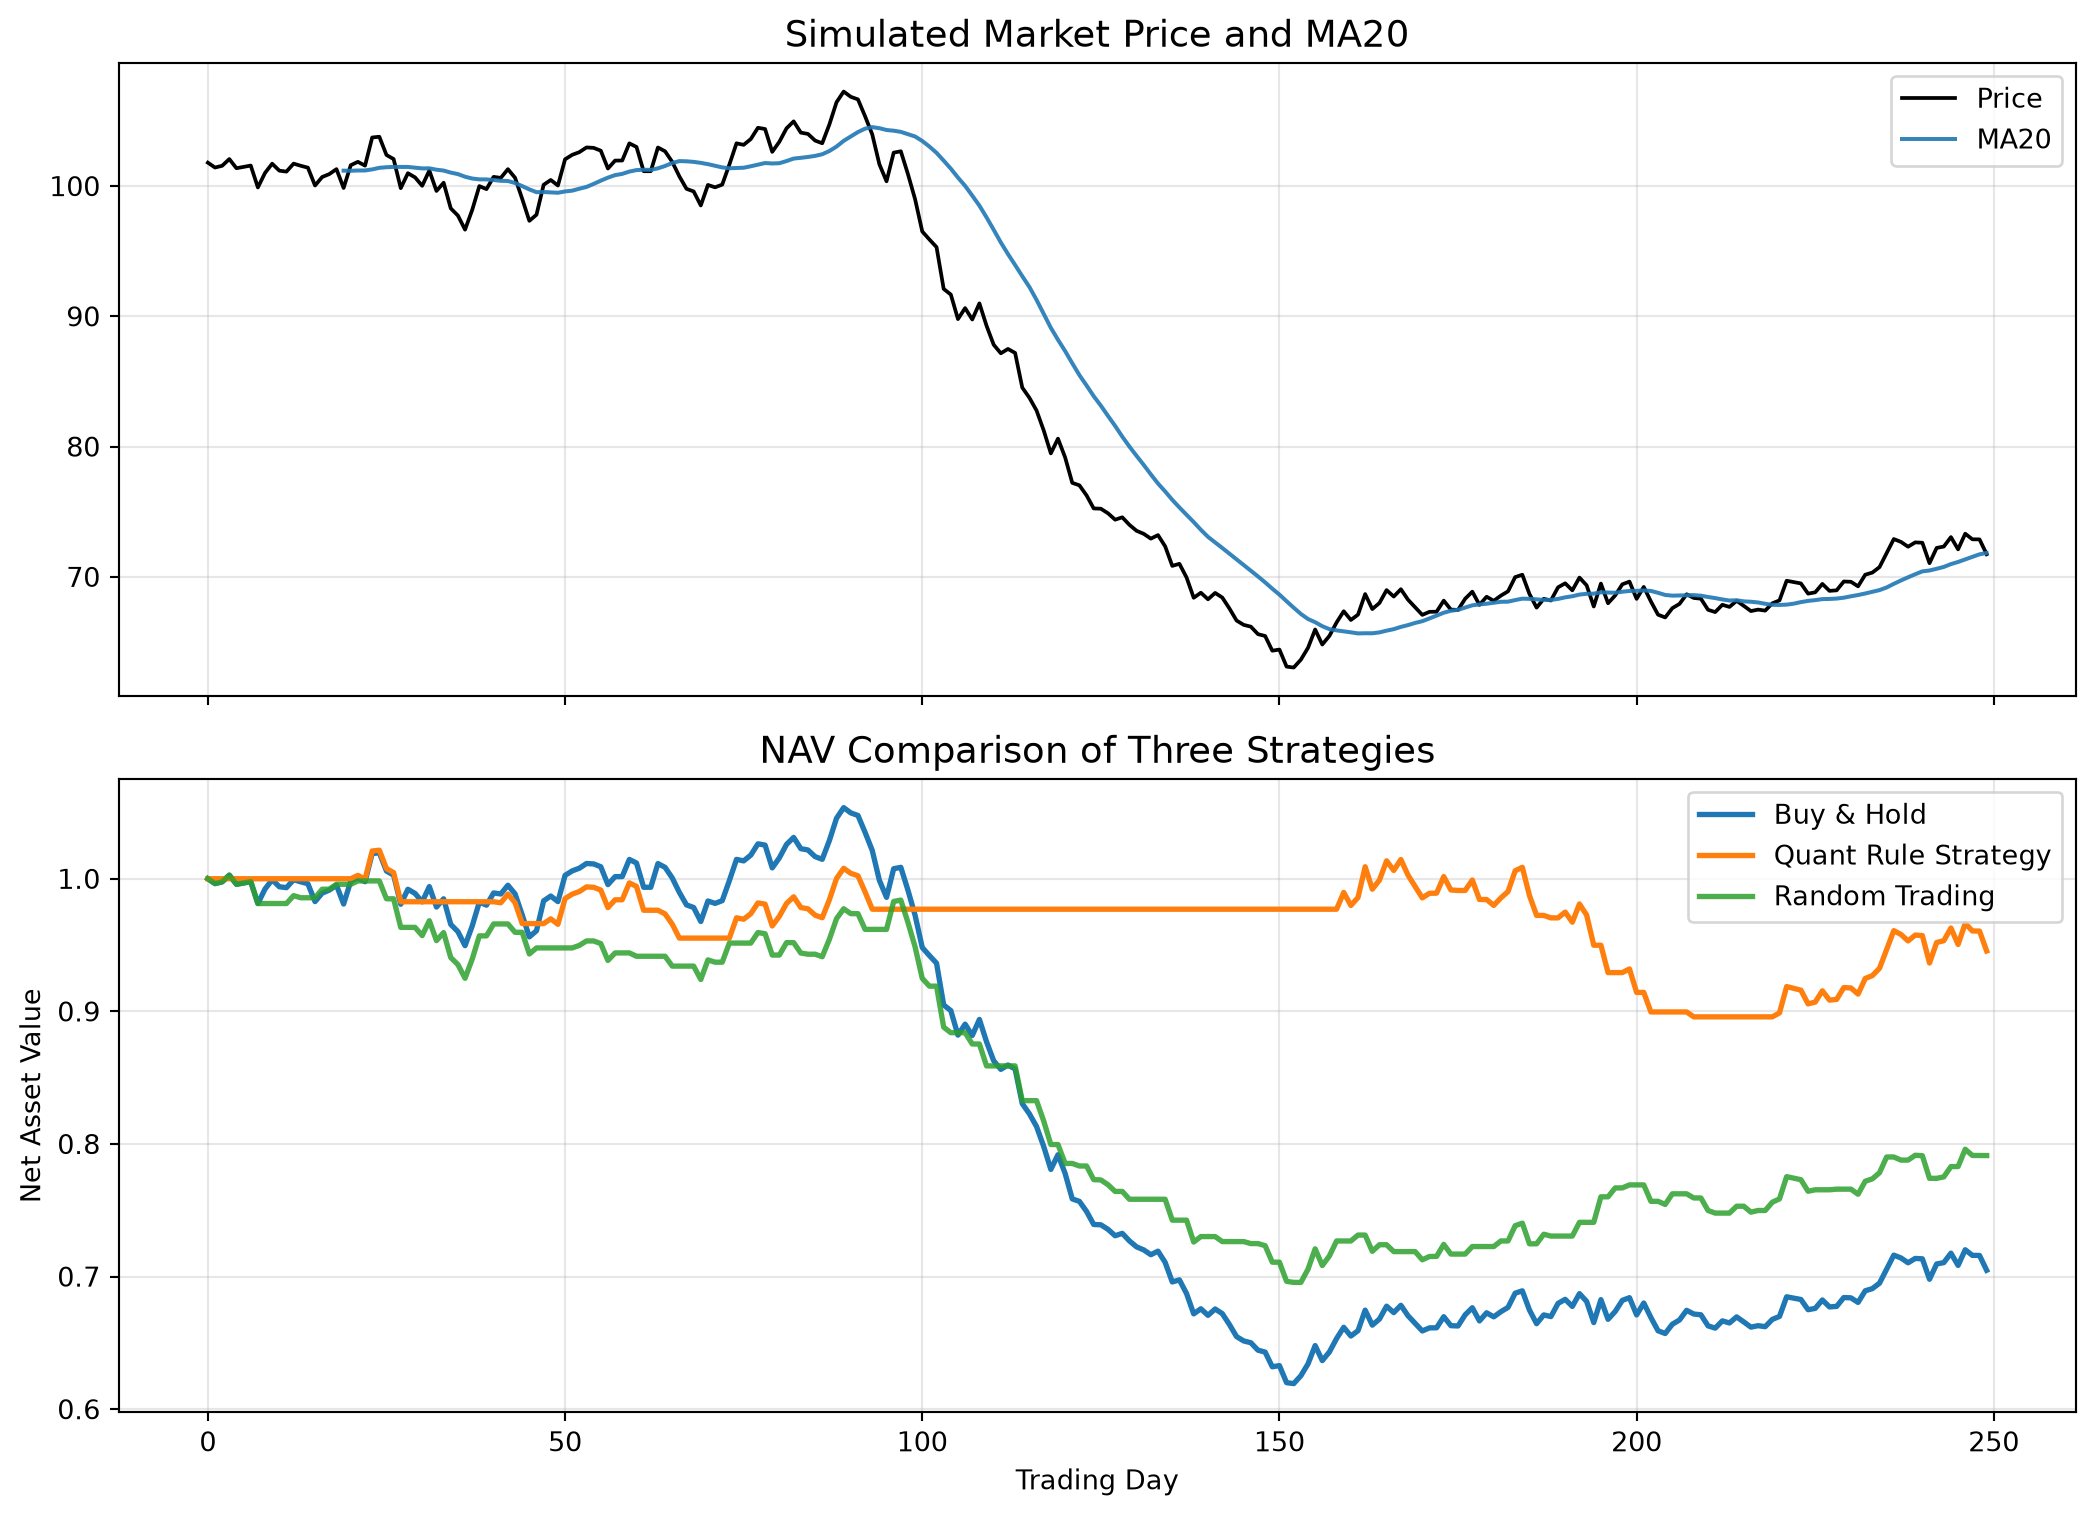

In [2]:
# ========== 导入本实验需要的库 ==========
import numpy as np  # 做数值计算（随机数、累乘价格等）
import pandas as pd  # 处理表格数据（像 Excel 一张表）
import matplotlib.pyplot as plt  # 画折线图、对比图
import os
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

plt.rcParams["axes.unicode_minus"] = False  # 让坐标轴上的负号正常显示
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "sans-serif"]  # 新增这一行
np.random.seed(7)  # 固定随机种子：每次运行随机数相同，方便对照

# ========== 第1步：模拟三段行情（涨→跌→恢复）==========
n1, n2, n3 = 90, 40, 120  # 三个阶段分别有多少个交易日
ret = np.r_[  # 把三段「日收益率」拼成一条长数组
    np.random.normal(0.0010, 0.010, n1),  # 阶段1：平均每天略涨，波动较小
    np.random.normal(-0.012, 0.015, n2),  # 阶段2：平均每天偏跌，波动更大
    np.random.normal(0.0012, 0.012, n3),  # 阶段3：震荡恢复
]  # 数组拼接结束
price = 100 * np.cumprod(1 + ret)  # 起点100元，每天按 (1+收益率) 连乘得到价格

# ========== 第2步：做成 DataFrame，并算每日涨跌比例 ==========
df = pd.DataFrame({"close": price})  # 把价格放进表格，列名叫 close
df["ret"] = df["close"].pct_change().fillna(0)  # pct_change = 日收益率；第一天填 0

# ========== 第3步：量化规则——收盘价在MA20上方就持有 ==========
df["ma20"] = df["close"].rolling(20).mean()  # rolling(20).mean() = 20日移动平均线
df["signal_quant"] = (df["close"] > df["ma20"]).astype(int)  # 高于均线记1，否则记0

# ========== 第4步：随机买卖策略（对照组，乱买乱卖）==========
rng = np.random.default_rng(7)  # 随机数生成器（种子7）
df["signal_random"] = rng.integers(0, 2, size=len(df))  # 每天随机 0 或 1

# ========== 第5步：算各策略的日收益（信号用昨天的，避免偷看未来）==========
df["ret_quant"] = df["signal_quant"].shift(1).fillna(0) * df["ret"]  # 量化策略收益
df["ret_random"] = df["signal_random"].shift(1).fillna(0) * df["ret"]  # 随机策略收益
df["ret_buyhold"] = df["ret"]  # 买入并持有：天天在场

# ========== 第6步：把日收益连乘成「净值曲线」（起点相当于1块钱）==========
for col in ["ret_quant", "ret_random", "ret_buyhold"]:  # 遍历三种收益列
    df[f"nav_{col}"] = (1 + df[col]).cumprod()  # (1+r) 连乘 = 累计净值

# ========== 第7步：画图——上图价格+均线，下图三种净值 ==========
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)  # 2行1列子图，共用横轴

axes[0].plot(df["close"], label="Price", color="black", linewidth=1.4)  # 模拟收盘价
axes[0].plot(df["ma20"], label="MA20", color="tab:blue", alpha=0.9)  # MA20
axes[0].set_title("Simulated Market Price and MA20", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df["nav_ret_buyhold"], label="Buy & Hold", linewidth=2)  # 买入持有净值
axes[1].plot(
    df["nav_ret_quant"], label="Quant Rule Strategy", linewidth=2
)  # 规则策略净值
axes[1].plot(
    df["nav_ret_random"], label="Random Trading", linewidth=2, alpha=0.85
)  # 随机策略
axes[1].set_title("NAV Comparison of Three Strategies", fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlabel("Trading Day")
axes[1].set_ylabel("Net Asset Value")

plt.tight_layout()  # 自动调整子图间距，避免标签被裁切
plt.show()  # 在 Notebook 里显示图片

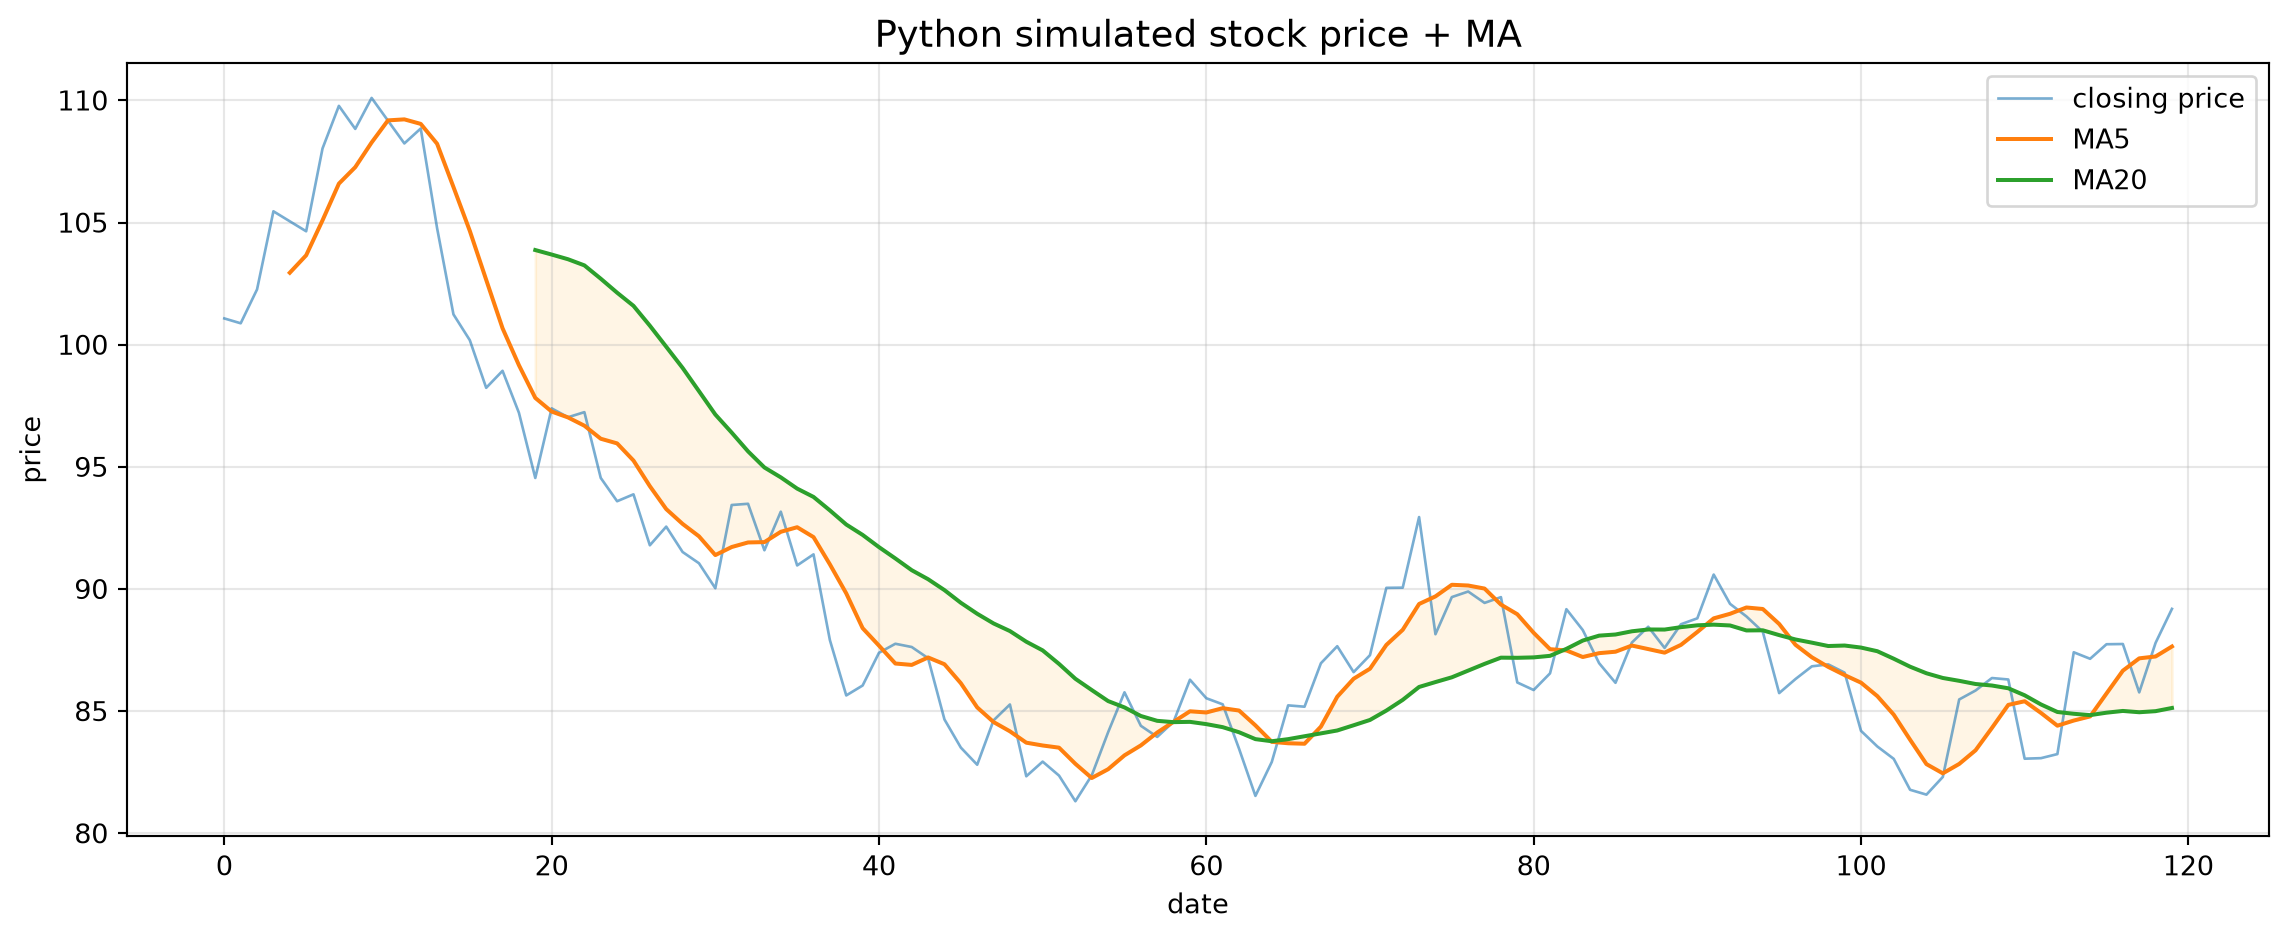

Starting price: ¥101.07
Final price: ¥89.18
Total return: -11.76%
Minimum price: ¥81.31
Maximum price: ¥110.10


In [3]:
# ========== 导入库 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import pandas as pd                      # 表格数据处理（像 Excel）
import matplotlib.pyplot as plt          # 绘图库（折线图、柱状图等）

plt.rcParams["axes.unicode_minus"] = False  # 坐标轴负号正常显示

np.random.seed(42)          # 固定随机数，结果可复现
days = 120                  # 一共模拟 120 个交易日
daily_returns = np.random.normal(loc=0.0008, scale=0.02, size=days)  # 每天随机收益率
price = 100 * np.cumprod(1 + daily_returns)     # 从100元出发连乘成价格序列

df = pd.DataFrame(
    {  # 构建表格
        "closing price": price,                              # 原始模拟收盘价
        "MA5": pd.Series(price).rolling(5).mean(),          # 最近5天均价
        "MA20": pd.Series(price).rolling(20).mean(),        # 最近20天均价
    }
)

plt.figure(figsize=(12, 5))                     # 创建画布，宽12高5英寸
plt.plot(df["closing price"], label="closing price", alpha=0.6, linewidth=1)
plt.plot(df["MA5"], label="MA5", linewidth=1.5)
plt.plot(df["MA20"], label="MA20", linewidth=1.5)
plt.fill_between(
    range(days), df["MA5"], df["MA20"], alpha=0.1, color="orange"
)  # 两线之间浅色填充
plt.title("Python simulated stock price + MA", fontsize=14)
plt.xlabel("date")
plt.ylabel("price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting price: ¥{price[0]:.2f}")
print(f"Final price: ¥{price[-1]:.2f}")
print(f"Total return: {(price[-1] / price[0] - 1) * 100:.2f}%")
print(f"Minimum price: ¥{price.min():.2f}")
print(f"Maximum price: ¥{price.max():.2f}")

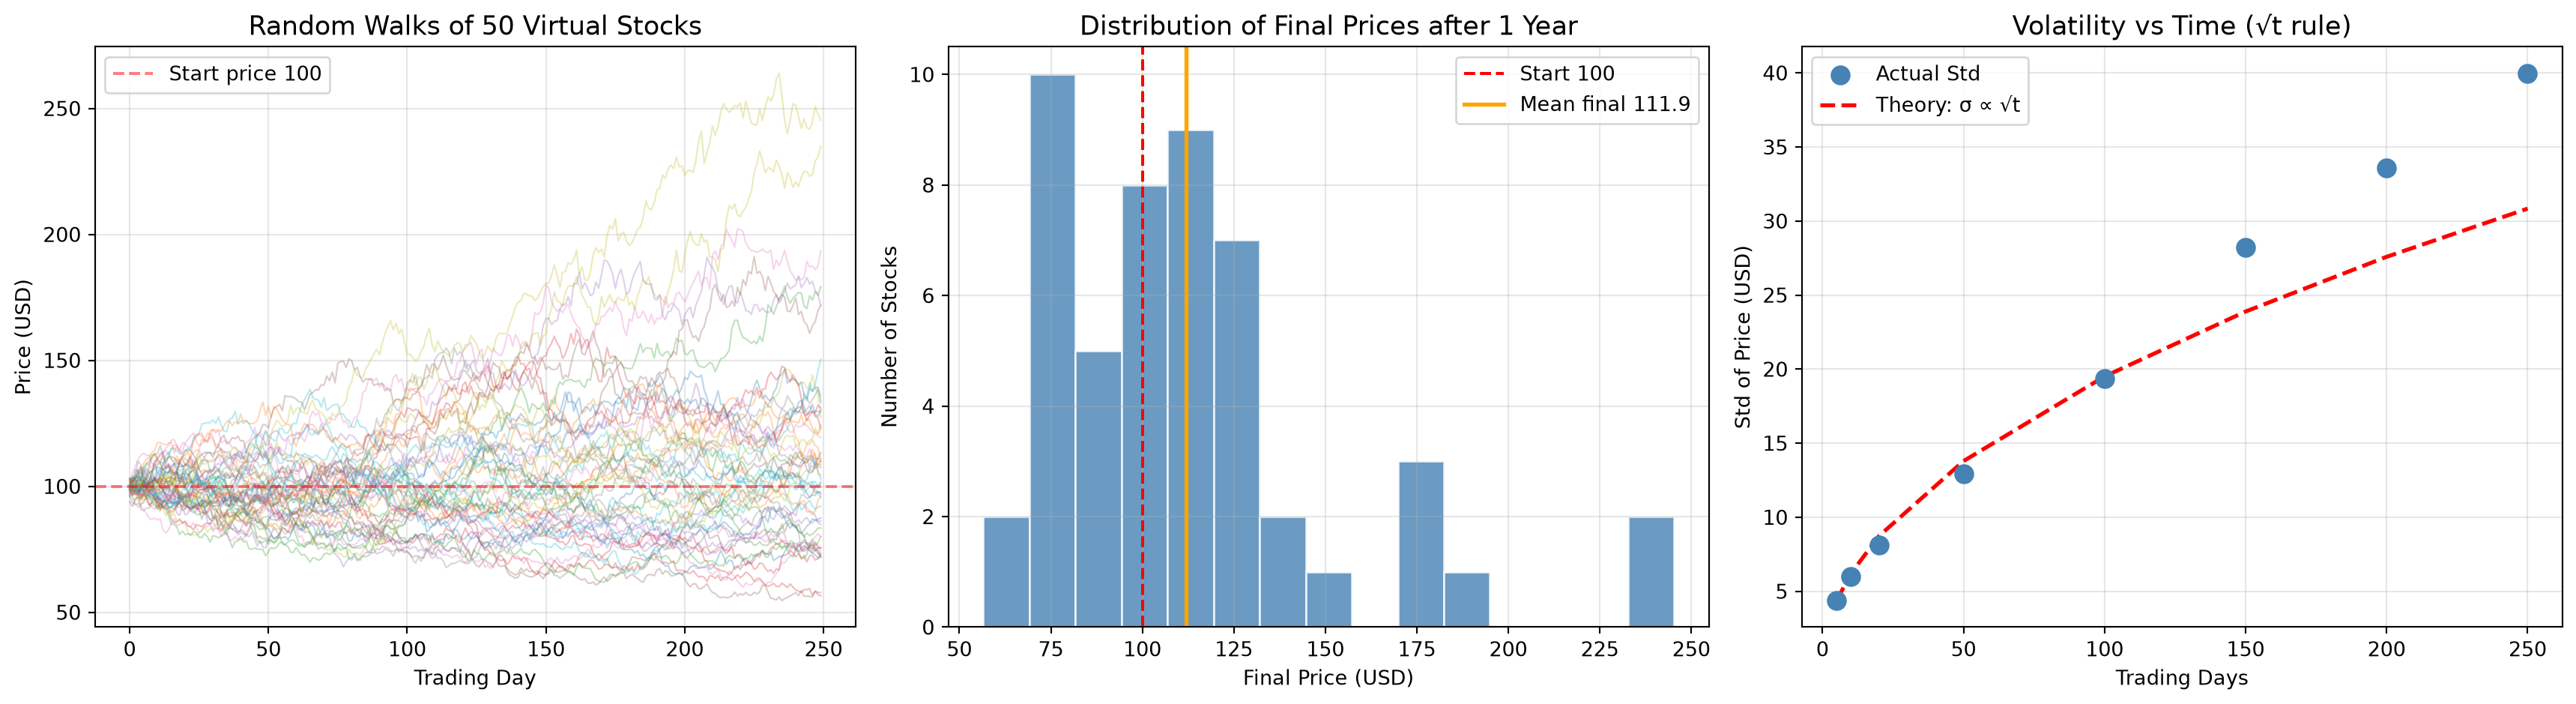

Experiment conclusions:
  50 stocks all started at 100 USD
  Highest final price: 245.32 USD
  Lowest final price:  56.49 USD
  Average final price: 111.92 USD
  Std of final prices: 39.98 USD
------------------------------------------------------------
  → Each individual path is unpredictable (left)
  → But the ensemble of final prices forms a normal distribution (middle)
  → Volatility grows with the square root of time (right) – Regnault's 1860s discovery!


In [4]:
# ========== 实验一：布朗运动 / 随机游走 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams["axes.unicode_minus"] = False      # 坐标轴负号正常显示

np.random.seed(2026)        # 固定随机种子

n_stocks = 50               # 模拟 50 只「虚拟股票」
n_days = 250                # 每只走 250 个交易日（约一年）
start_price = 100           # 起始价都是 100 元
daily_volatility = 0.02     # 日波动强度（标准差约2%）

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1行3列，三个子图

# --- 左图：画出 50 条价格路径 ---
all_paths = []              # 用来存每只股票的路径
for _ in range(n_stocks):   # 循环 50 次，每只股一条路径
    daily_returns = np.random.normal(0, daily_volatility, n_days)  # 每天随机收益
    price_path = start_price * np.cumprod(1 + daily_returns)       # 价格连乘
    all_paths.append(price_path)          # 存入列表
    axes[0].plot(price_path, alpha=0.3, linewidth=0.8)  # 画在左图，半透明

axes[0].axhline(y=start_price, color='red', linestyle='--', alpha=0.5, label='Start price 100')
axes[0].set_title('Random Walks of 50 Virtual Stocks', fontsize=13)
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- 中图：一年后的终点价格分布（直方图）---
final_prices = [path[-1] for path in all_paths]   # 取每条路径最后一天的价格
axes[1].hist(final_prices, bins=15, color='steelblue', edgecolor='white', alpha=0.8)  # 画直方图
axes[1].axvline(x=start_price, color='red', linestyle='--', label=f'Start {start_price}')
axes[1].axvline(x=np.mean(final_prices), color='orange', linestyle='-', linewidth=2,
                label=f'Mean final {np.mean(final_prices):.1f}')
axes[1].set_title('Distribution of Final Prices after 1 Year', fontsize=13)
axes[1].set_xlabel('Final Price (USD)')
axes[1].set_ylabel('Number of Stocks')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- 右图：验证「波动 ∝ 时间的平方根」---
time_points = [5, 10, 20, 50, 100, 150, 200, 250]  # 选取若干观察日
std_at_time = []                                    # 存放每个时点的价格标准差
for t in time_points:  # 代码块开始
    prices_at_t = [path[t-1] for path in all_paths]  # 所有股票在第 t 天的价格
    std_at_time.append(np.std(prices_at_t))         # 算标准差

sqrt_time = np.sqrt(time_points)                    # 时间开平方
scale = std_at_time[0] / sqrt_time[0]               # 缩放系数，让理论线对齐第一个点

axes[2].scatter(time_points, std_at_time, s=80, color='steelblue', zorder=5, label='Actual Std')
axes[2].plot(time_points, scale * sqrt_time, 'r--', linewidth=2, label='Theory: σ ∝ √t')
axes[2].set_title('Volatility vs Time (√t rule)', fontsize=13)
axes[2].set_xlabel('Trading Days')
axes[2].set_ylabel('Std of Price (USD)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

# ========== 打印文字结论 ==========
print("=" * 60)
print("Experiment conclusions:")
print(f"  50 stocks all started at {start_price} USD")
print(f"  Highest final price: {max(final_prices):.2f} USD")
print(f"  Lowest final price:  {min(final_prices):.2f} USD")
print(f"  Average final price: {np.mean(final_prices):.2f} USD")
print(f"  Std of final prices: {np.std(final_prices):.2f} USD")
print("-" * 60)
print("  → Each individual path is unpredictable (left)")
print("  → But the ensemble of final prices forms a normal distribution (middle)")
print("  → Volatility grows with the square root of time (right) – Regnault's 1860s discovery!")
print("=" * 60)

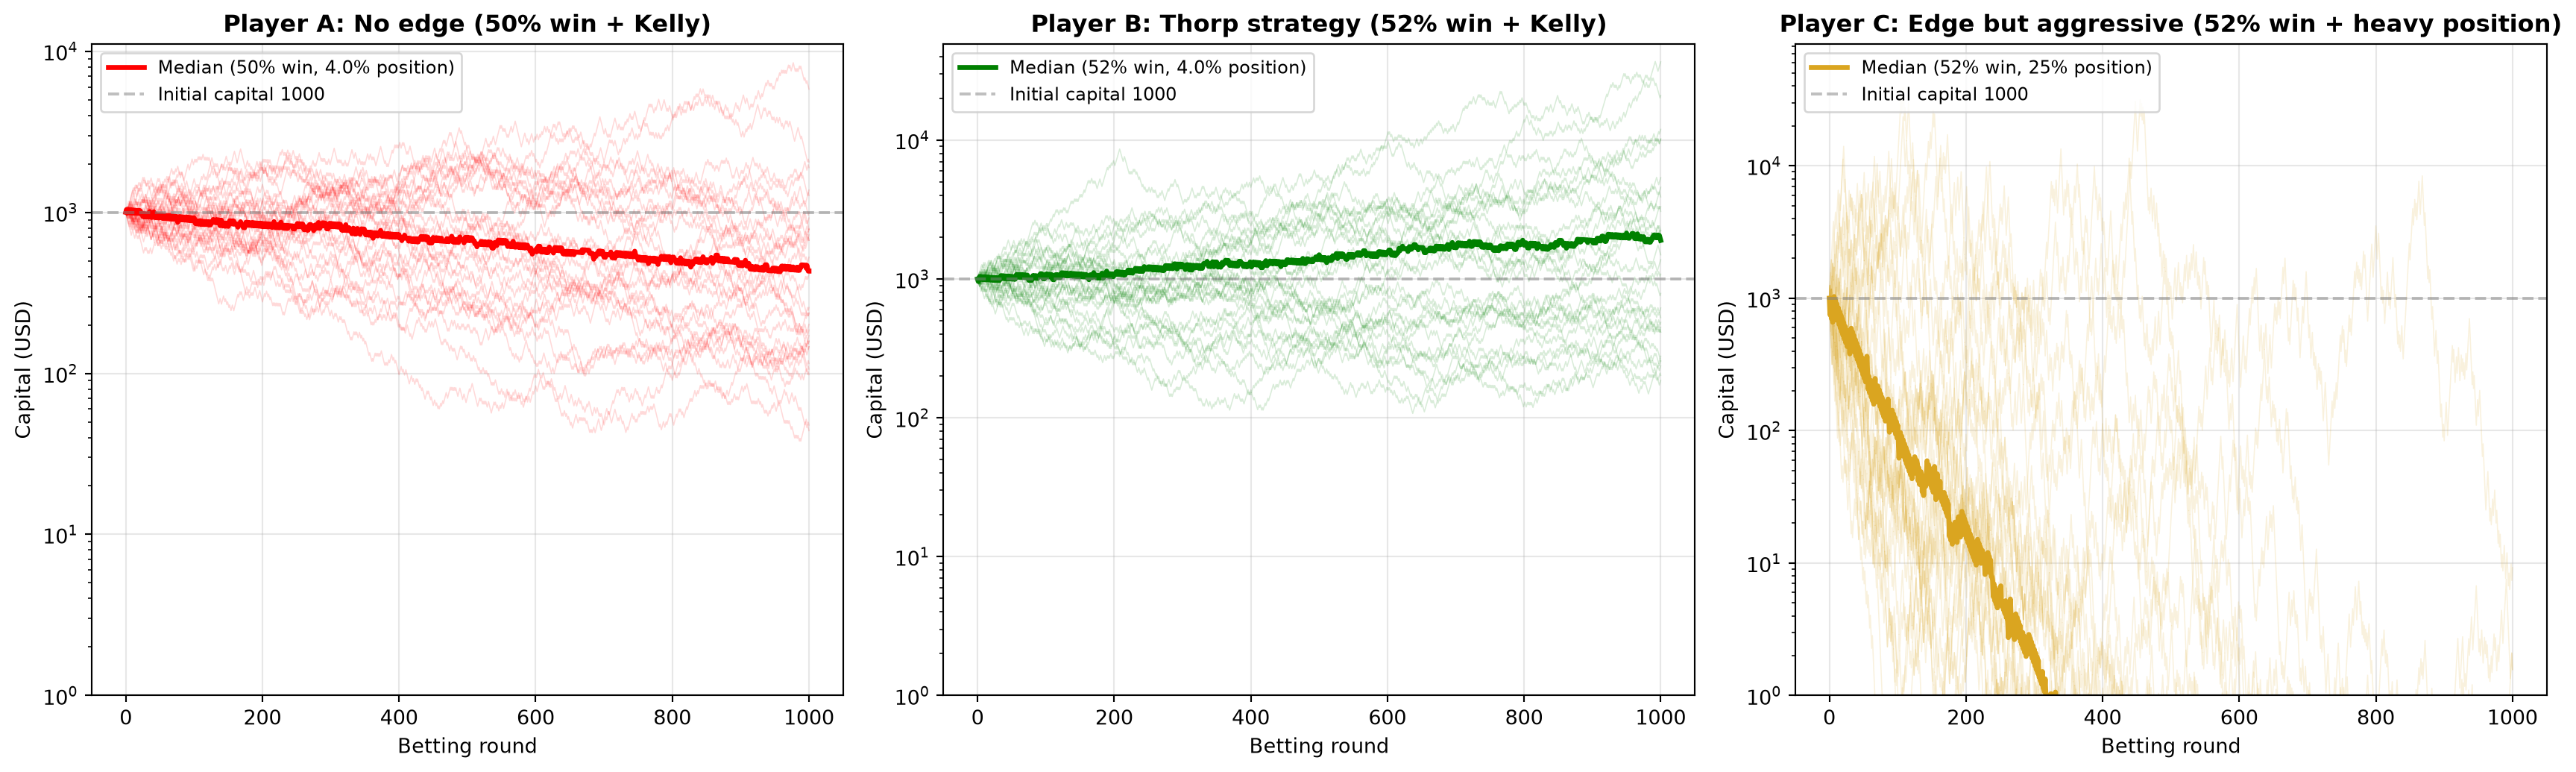

Kelly formula: optimal f* = 4.00% (win 52%, odds 1:1)

  【Player A (no edge)】
    Median final capital: 432 USD
    Win probability: 23.5%
    Best case: 43,026 USD | Worst case: 13.27 USD

  【Player B (Thorp)】
    Median final capital: 1,897 USD
    Win probability: 70.5%
    Best case: 50,495 USD | Worst case: 90.58 USD

  【Player C (aggressive)】
    Median final capital: 0 USD
    Win probability: 0.0%
    Best case: 916 USD | Worst case: 0.01 USD

  → No edge, Kelly cannot save you (Player A)
  → Just 2% win advantage + scientific position sizing = long‑term compound growth (Player B)
  → Edge with over‑betting can lead to ruin (Player C)
  → Thorp's core insight: probability edge × position sizing = quantitative profit formula


In [5]:
# ========== 实验二：索普——概率优势 + 凯利仓位 ==========
import numpy as np                       # 数值计算（数组、随机数、统计）
import matplotlib.pyplot as plt            # 绘图库（折线图、柱状图等）

plt.rcParams["axes.unicode_minus"] = False      # 坐标轴负号正常显示

np.random.seed(2026)  # 固定随机种子，结果可复现

n_rounds = 1000             # 每位玩家模拟下注 1000 轮
n_simulations = 200         # 每种策略重复 200 次（看分布）
initial_capital = 1000      # 初始本金 1000 元

win_prob_no_edge = 0.50     # 玩家A：无优势，胜率 50%
win_prob_edge = 0.52        # 玩家B/C：有 2% 概率优势
payout_ratio = 1.0          # 赔率 1:1（赢一倍赌注，输一倍赌注）

# 凯利公式: f* = (bp - q) / b  → 最优下注占本金比例
kelly_fraction = (payout_ratio * win_prob_edge - (1 - win_prob_edge)) / payout_ratio  # 凯利公式最优下注比例
aggressive_fraction = 0.25  # 玩家C：有优势但每次下注 25%（太激进）


def simulate_player(win_prob, bet_fraction, n_sims=n_simulations):  # 定义模拟下注函数
    """模拟多人在 n_rounds 轮里的资金曲线。"""  # 字典字段
    all_curves = []              # 存放每次实验的资金曲线
    for _ in range(n_sims):              # 外层：重复很多次实验
        capital = initial_capital        # 本轮起始资金
        curve = [capital]              # 记录每轮后的资金
        for _ in range(n_rounds):      # 内层：一轮轮下注
            bet = capital * bet_fraction   # 本轮下注额 = 本金 × 比例
            if np.random.random() < win_prob:  # 随机数小于胜率 → 赢
                capital += bet * payout_ratio  # 赢：拿回赌注并赚一倍
            else:                              # 否则 → 输
                capital -= bet                 # 输：输掉本轮赌注
            capital = max(capital, 0.01)       # 防止资金变成负数
            curve.append(capital)  # 执行本行代码
        all_curves.append(curve)  # 执行本行代码
    return np.array(all_curves)        # 转成二维数组：行=实验，列=轮次


curves_A = simulate_player(win_prob_no_edge, kelly_fraction)       # 无优势 + 凯利
curves_B = simulate_player(win_prob_edge, kelly_fraction)          # 有优势 + 凯利
curves_C = simulate_player(win_prob_edge, aggressive_fraction)     # 有优势 + 重仓

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))  # 三个玩家各一张子图

configs = [  # 三个子图的配置
    (curves_A, 'Player A: No edge (50% win + Kelly)', 'red', f'50% win, {kelly_fraction*100:.1f}% position'),
    (curves_B, 'Player B: Thorp strategy (52% win + Kelly)', 'green', f'52% win, {kelly_fraction*100:.1f}% position'),
    (curves_C, 'Player C: Edge but aggressive (52% win + heavy position)', 'goldenrod', '52% win, 25% position'),
]

for ax, (curves, title, color, label) in zip(axes, configs):  # 为每个玩家画子图
    for i in range(min(30, n_simulations)):   # 只画前30条细线，避免太乱
        ax.plot(curves[i], alpha=0.15, linewidth=0.6, color=color)  # 在子图上画折线
    median_curve = np.median(curves, axis=0)  # 200次实验的中位数轨迹
    ax.plot(median_curve, color=color, linewidth=2.5, label=f'Median ({label})')  # 在子图上画折线
    ax.axhline(y=initial_capital, color='gray', linestyle='--', alpha=0.5, label=f'Initial capital {initial_capital}')
    ax.set_title(title, fontsize=12, fontweight='bold')  # 设置子图标题
    ax.set_xlabel('Betting round')  # 设置子图横轴
    ax.set_ylabel('Capital (USD)')  # 设置子图纵轴
    ax.legend(fontsize=9, loc='upper left')  # 显示图例
    ax.grid(True, alpha=0.3)  # 显示网格
    ax.set_yscale('log')      # 纵轴用对数刻度，差距大时更好看
    ax.set_ylim(1, None)  # 设置纵轴范围

plt.tight_layout()                       # 自动调整子图间距，避免标签被裁切
plt.show()                               # 在 Notebook 里显示图片

print("=" * 70)
print(f"Kelly formula: optimal f* = {kelly_fraction*100:.2f}% (win 52%, odds 1:1)")
print("=" * 70)

for name, curves, color in [("Player A (no edge)", curves_A, "red"),
                              ("Player B (Thorp)", curves_B, "green"),
                              ("Player C (aggressive)", curves_C, "goldenrod")]:
    finals = curves[:, -1]                    # 每个实验最后一轮的资金
    win_rate = np.mean(finals > initial_capital) * 100  # 最终赚钱的比例
    median_final = np.median(finals)  # 赋值：median_final
    print(f"\n  【{name}】")
    print(f"    Median final capital: {median_final:,.0f} USD")
    print(f"    Win probability: {win_rate:.1f}%")
    print(f"    Best case: {np.max(finals):,.0f} USD | Worst case: {np.min(finals):,.2f} USD")

print("\n" + "=" * 70)
print("  → No edge, Kelly cannot save you (Player A)")
print("  → Just 2% win advantage + scientific position sizing = long‑term compound growth (Player B)")
print("  → Edge with over‑betting can lead to ruin (Player C)")
print("  → Thorp's core insight: probability edge × position sizing = quantitative profit formula")
print("=" * 70)

✅ AAPL data loaded, total 124 trading days
   Date range: 2026-01-20  ~ 2026-07-17
   Latest close: $333.74


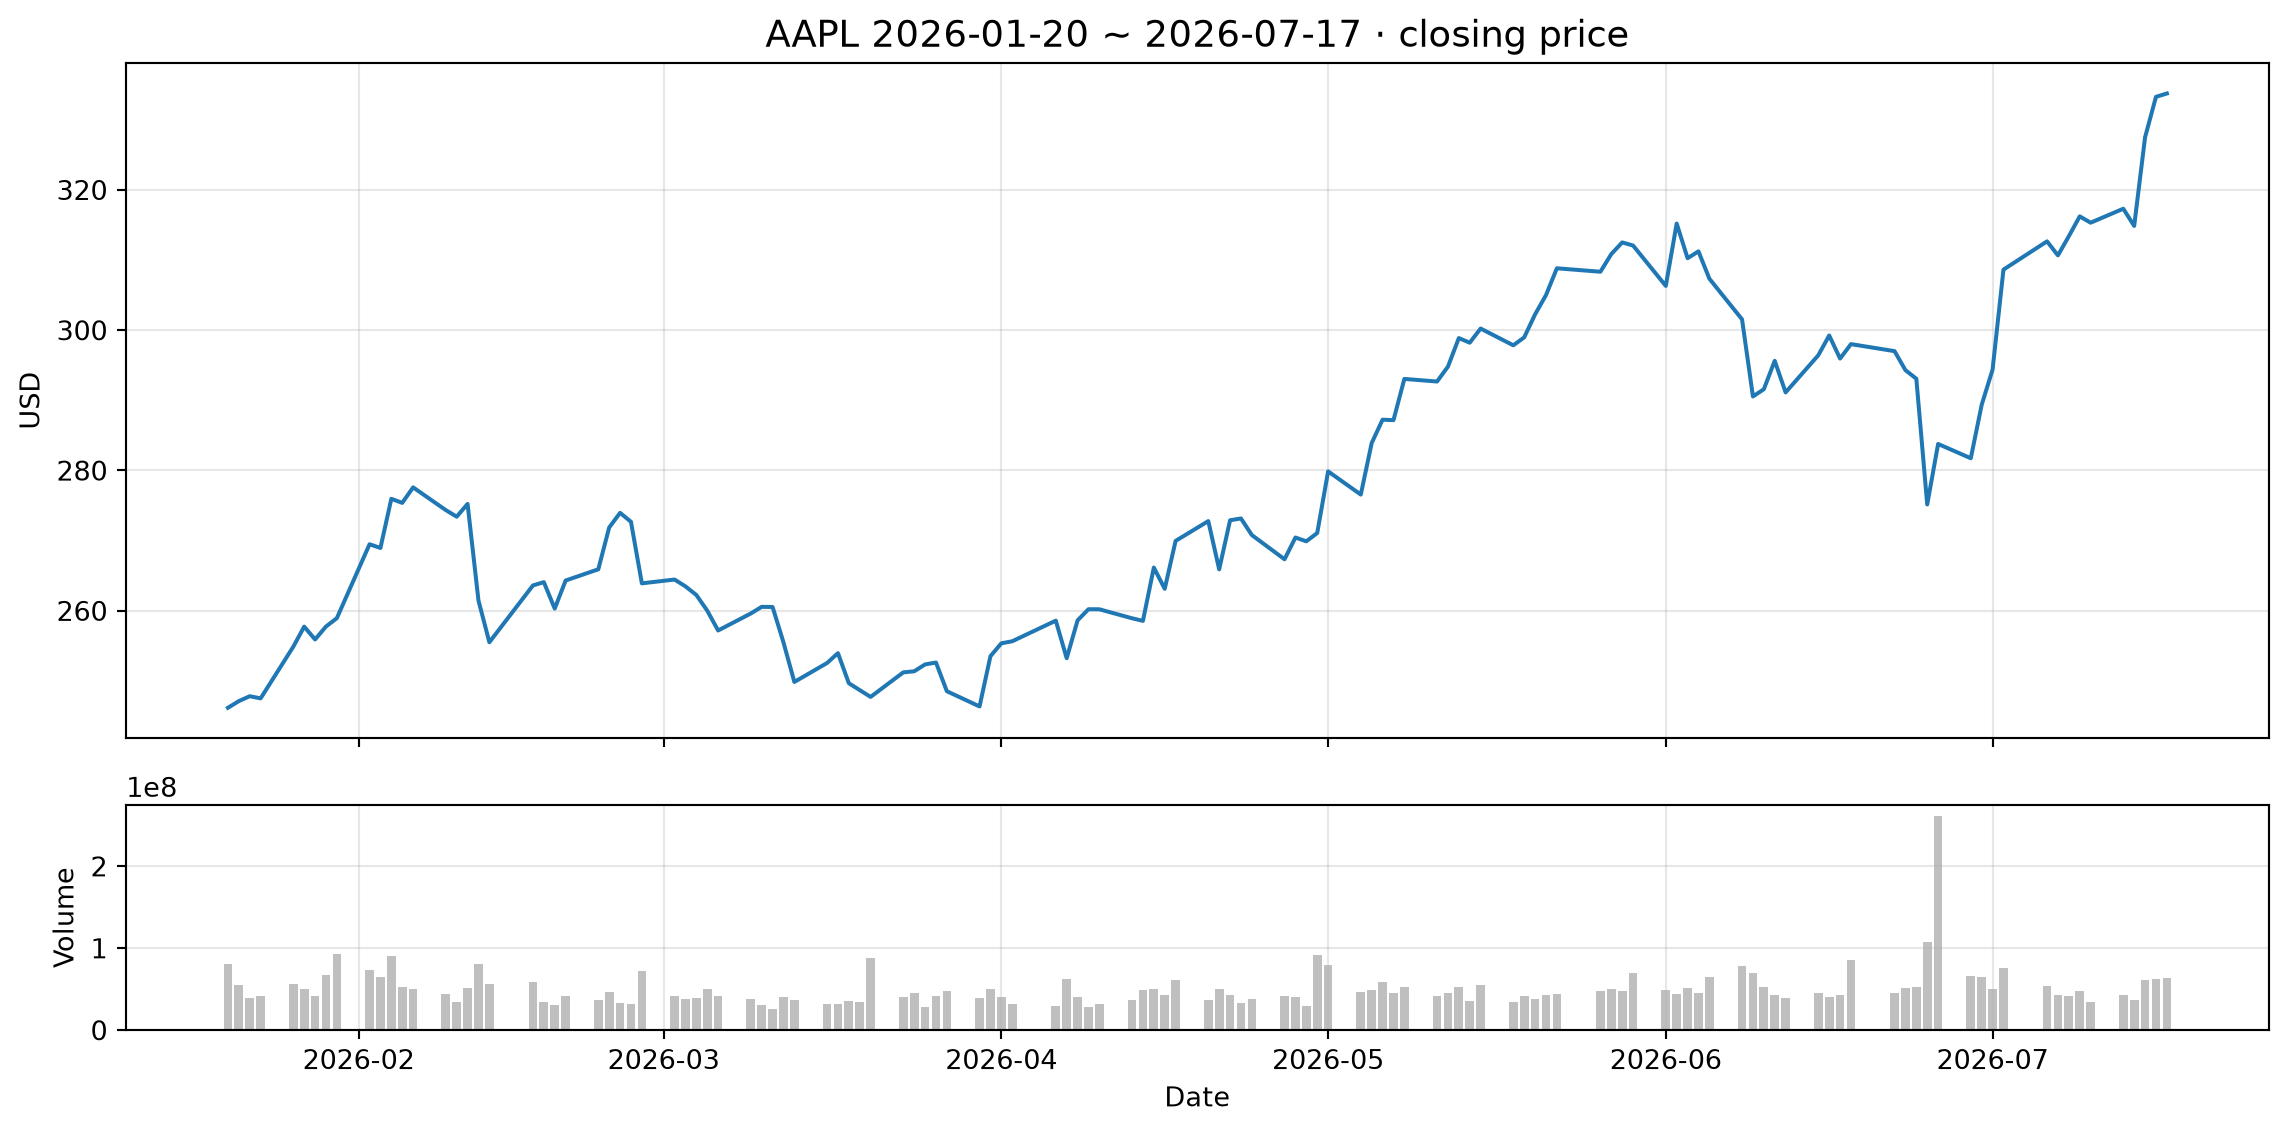

In [6]:
#| label: fig-stock-price
#| fig-cap: AAPL 近六个月收盘价
#| echo: false
# ========== 第一章：下载真实股票数据 ==========

import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import akshare as ak
import matplotlib.pyplot as plt
from datetime import datetime

plt.rcParams["axes.unicode_minus"] = False


def get_stock_data(symbol, start_date=None, end_date=None, adjust="qfq"):
    """
    下载美股日线数据，返回处理后的 DataFrame（日期为索引）

    参数：
        symbol : str，股票代码，如 'AAPL'
        start_date : str，起始日期 'YYYY-MM-DD'，默认为 None -> 自动取近六个月前
        end_date   : str，结束日期 'YYYY-MM-DD'，默认为 None -> 自动取今天
        adjust : str，复权类型，默认 'qfq'（前复权）

    返回：
        pd.DataFrame，列名：Open, High, Low, Close, Volume（首字母大写）
    """
    # 1. 若未指定日期，自动计算默认值
    if start_date is None and end_date is None:
        end_date = datetime.now().strftime("%Y-%m-%d")
        start_date = (pd.Timestamp.now() - pd.DateOffset(months=6)).strftime("%Y-%m-%d")
    elif end_date is None:
        end_date = datetime.now().strftime("%Y-%m-%d")
    elif start_date is None:
        start_date = "1900-01-01"  # 极早日期，表示不限制起始

    # 2. 下载全部历史数据（akshare 不支持直接传日期参数）
    df = ak.stock_us_daily(symbol=symbol, adjust=adjust)

    # 3. 本地按日期过滤（字符串比较，效率高）
    if start_date:
        df = df[df["date"] >= start_date]
    if end_date:
        df = df[df["date"] <= end_date]

    # 4. 若数据为空则提示并返回
    if df.empty:
        print(f"⚠️ No data found for {symbol} from {start_date} to {end_date}")
        return None

    # 5. 处理日期列、设为索引、列名首字母大写、按日期升序
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    df.columns = [col.capitalize() for col in df.columns]
    df = df.sort_index()

    # 6. 打印摘要信息（英文）
    print(f"✅ {symbol} data loaded, total {len(df)} trading days")
    print(f"   Date range: {df.index.min().date()}  ~ {df.index.max().date()}")
    print(f"   Latest close: ${df['Close'].iloc[-1]:.2f}")

    return df


def plot_stock(df, symbol=None, title=None):
    """
    绘制收盘价折线图和成交量柱状图（上下两张子图）

    参数：
        df : DataFrame，由 get_stock_data() 返回
        symbol : str，股票代码（用于生成标题，如 'AAPL'）
        title : str，自定义标题（若提供则覆盖自动生成的标题）
    """
    if df is None or len(df) == 0:
        print("No data to plot")
        return

    # 若未提供自定义标题，则自动生成：股票代码 + 日期范围 + "closing price"
    if title is None:
        date_range = f"{df.index.min().date()} ~ {df.index.max().date()}"
        if symbol:
            title = f"{symbol.upper()} {date_range} · closing price"
        else:
            title = f"{date_range} · closing price"

    fig, axes = plt.subplots(
        2, 1, figsize=(12, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
    )

    axes[0].plot(df.index, df["Close"], color="tab:blue", linewidth=1.5)
    axes[0].set_title(title, fontsize=14)  # 标题自动含股票代码和日期
    axes[0].set_ylabel("USD")
    axes[0].grid(True, alpha=0.3)

    axes[1].bar(df.index, df["Volume"], width=0.8, color="gray", alpha=0.5)
    axes[1].set_ylabel("Volume")
    axes[1].set_xlabel("Date")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ========== 使用示例 ==========

# 1. 默认：近六个月（自动）
df_aapl = get_stock_data("AAPL")
plot_stock(df_aapl, symbol="AAPL")

# 2. 指定日期范围（如 2025 年全年）
# df_msft = get_stock_data("MSFT", start_date="2025-01-01", end_date="2025-12-31")
# plot_stock(df_msft, symbol="MSFT")

# 3. 全部历史数据（将 start_date 设为很早即可）
# df_all = get_stock_data("AAPL", start_date="1980-01-01")
# plot_stock(df_all, symbol="AAPL")

✅ NVDA data loaded, total 124 trading days
   Date range: 2026-01-20  ~ 2026-07-17
   Latest close: $202.81


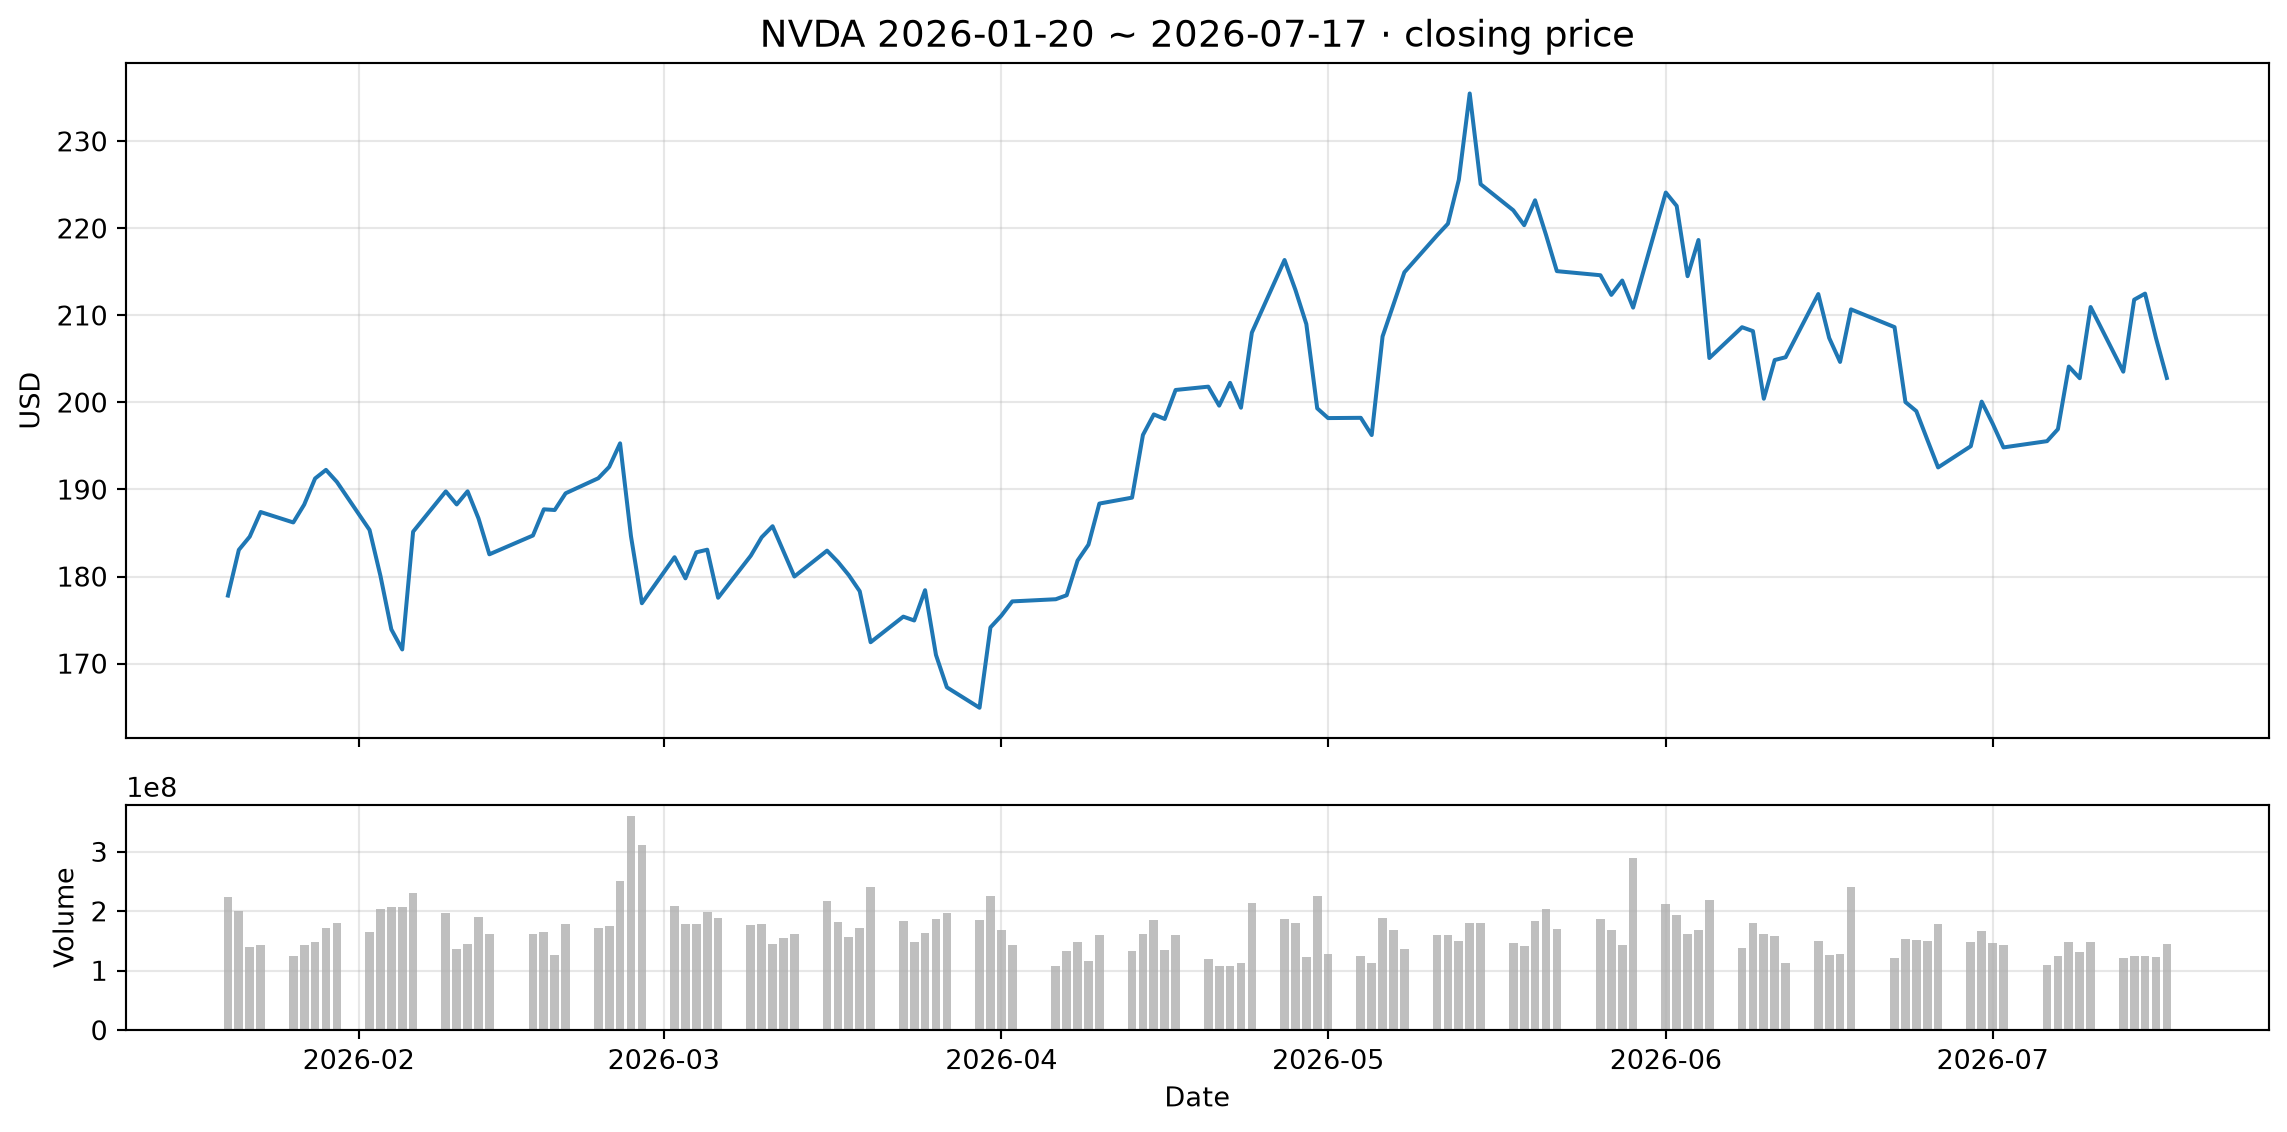

In [7]:
df_aapl = get_stock_data("NVDA")
plot_stock(df_aapl, symbol="NVDA")

✅ TSLA data loaded, total 124 trading days
   Date range: 2026-01-20  ~ 2026-07-17
   Latest close: $380.84


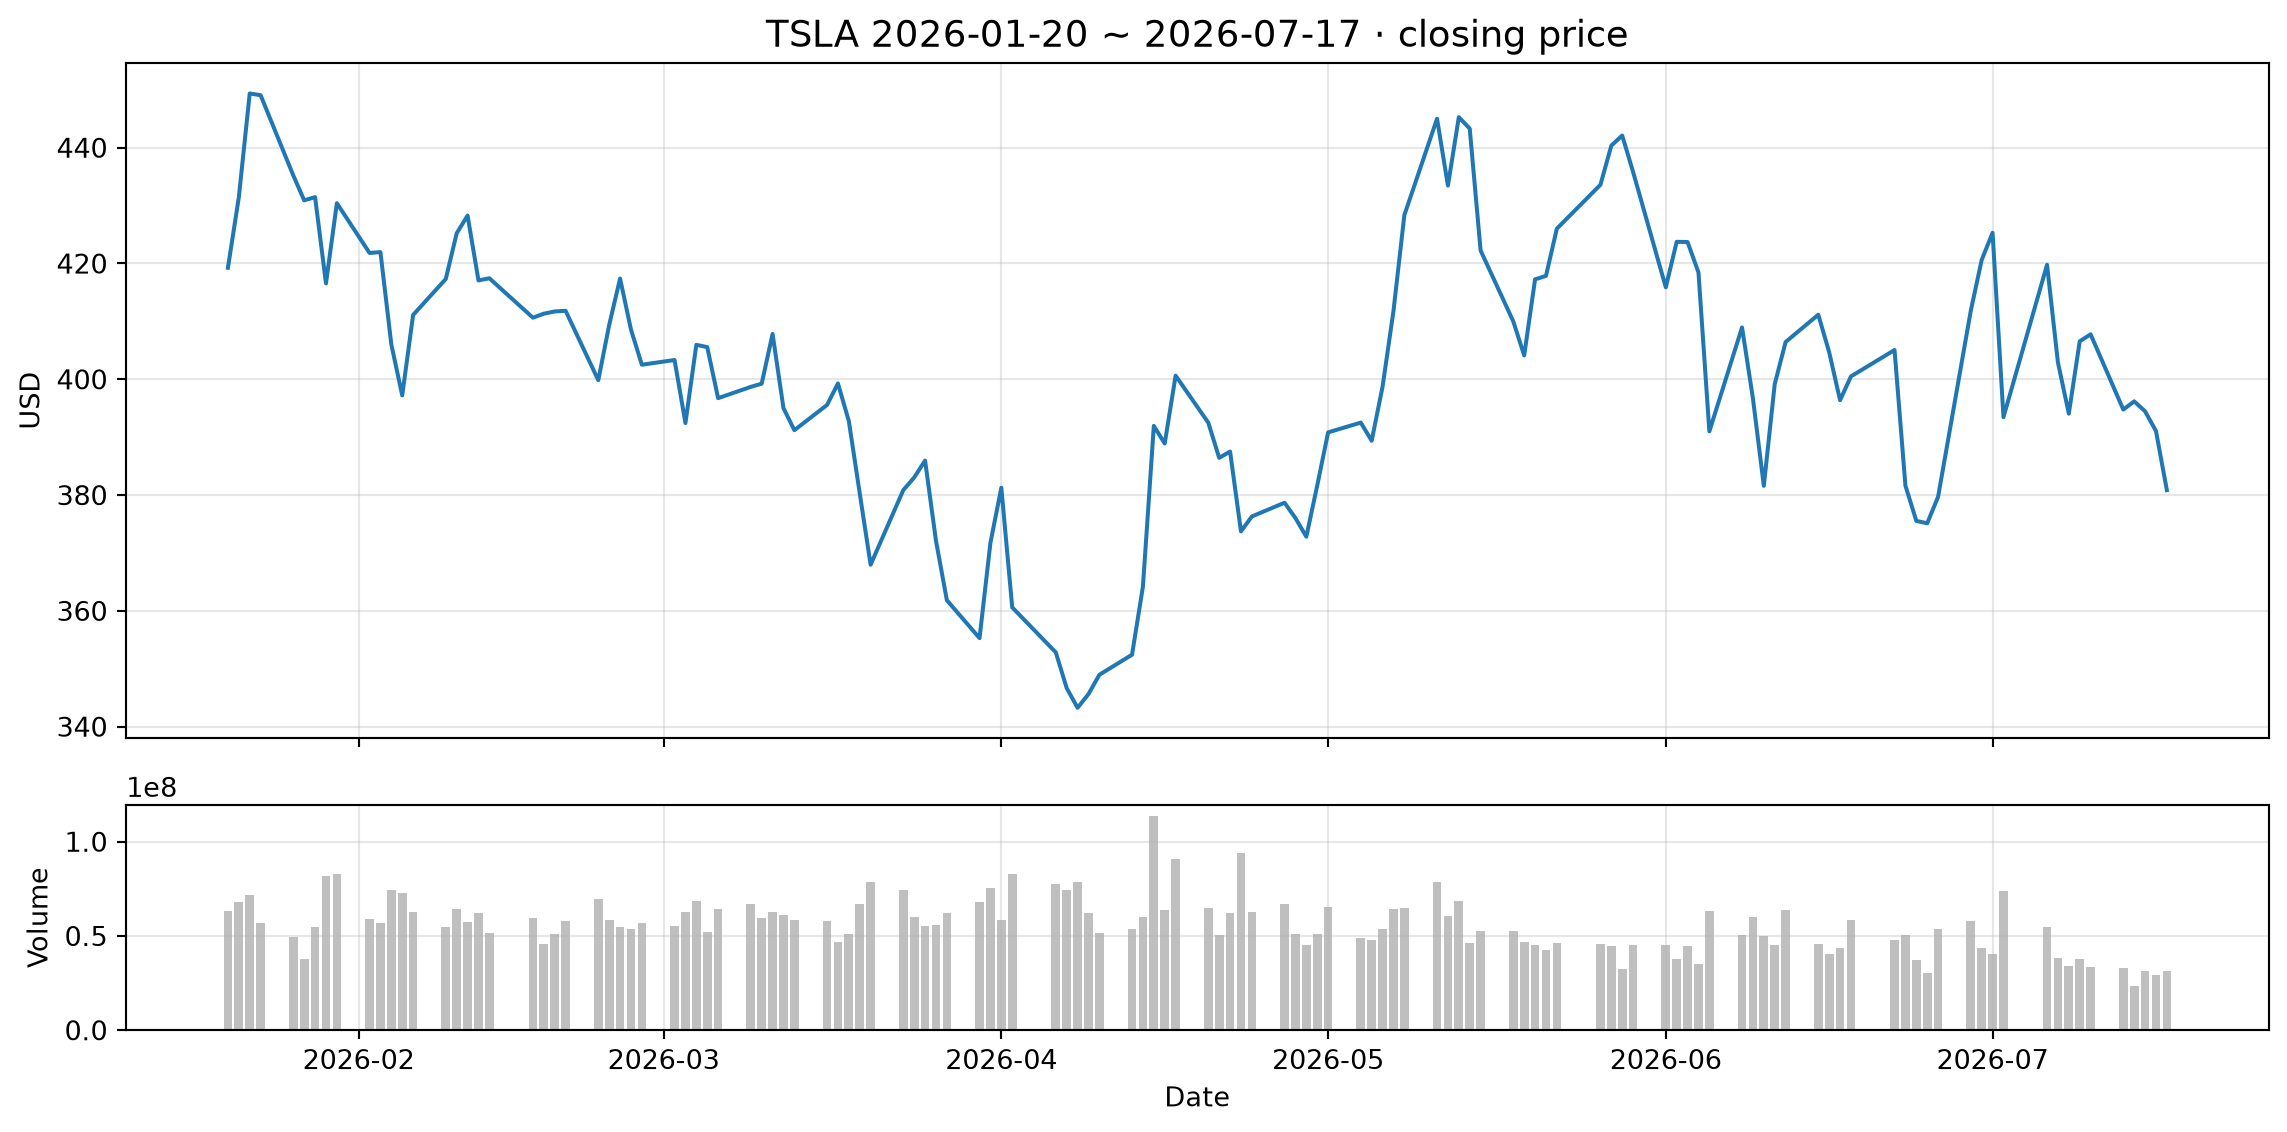

In [8]:
df_aapl = get_stock_data("TSLA")
plot_stock(df_aapl, symbol="TSLA")